## RichValues tutorial: Computing a ratio of two table columns

In this tutorial, we import a file of abundances of two molecules in several astronomical sources, we compute the ratio between both species for each source, make a plot of it and export the results.

First, let's import the modules and libraries to use.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import richvalues as rv

Let's import the data.

In [2]:
data = pd.read_csv('observed-column-densities.csv', index_col=0, comment='#')
data = rv.rich_dataframe(data, domains=[0,np.inf])
data

,HC3N,CH3CN
Source \ Molecule,,
L1517B - dust,5.16+/-0.05 e13,2.1+/-0.6 e11
L1517B - methanol,3.72-0.13+0.14 e12,< 2.0 e11
L1498 - dust,1.6+/-0.3 e13,< 8 e10
L1498 - methanol,2.2+/-1.0 e13,1.0+/-0.1 e11
L1544 - dust,1.0+/-0.3 e14,1.5+/-0.2 e11
L1544 - methanol,4.2+/-0.4 e13,< 9 e10
L1521E - dust,8.4+/-2.0 e12,4.8+/-1.0 e11
B1-a,4.2+/-1.0 e12,4.9+/-1.0 e11
B1-c,4+/-3 e12,3.5+/-0.6 e11


We want to compute the ratio between the two columns. It is very easy.

In [3]:
ratio = data['HC3N'] / data['CH3CN']
ratio

Source \ Molecule
L1517B - dust          250-60+90
L1517B - methanol           > 17
L1498 - dust                > 90
L1498 - methanol     220-100+110
L1544 - dust         660-210+240
L1544 - methanol           > 300
L1521E - dust            18-6+10
B1-a                       9-3+4
B1-c                    12-10+11
B5 IRS1                      > 6
HH 300                       nan
IRAS 03235              25-10+33
IRAS 03245              19-14+58
IRAS 03254                   nan
IRAS 03271                8-7+15
IRAS 04108                   nan
IRAS 23238              23-19+21
L1014 IRS                  > 1.4
L1448 IRS1                   nan
L1455 IRS3                 > 1.4
L1455 SMM1                   > 4
L1489 IRS                  > 0.5
SVS 4-5                   21-6+8
GM Aur                 8.9+/-2.0
As 209                    17-3+4
HD 163296                32-9+11
MWC 480                  22-8+11
46P                       < 0.21
67P                        0.068
dtype: object

We obtained a Pandas' series. Now, we add it to the original dataframe.

In [4]:
data['ratio'] = ratio
data

,HC3N,CH3CN,ratio
Source \ Molecule,,,
L1517B - dust,5.16+/-0.05 e13,2.1+/-0.6 e11,250-60+90
L1517B - methanol,3.72-0.13+0.14 e12,< 2.0 e11,> 17
L1498 - dust,1.6+/-0.3 e13,< 8 e10,> 90
L1498 - methanol,2.2+/-1.0 e13,1.0+/-0.1 e11,220-100+110
L1544 - dust,1.0+/-0.3 e14,1.5+/-0.2 e11,660-210+240
L1544 - methanol,4.2+/-0.4 e13,< 9 e10,> 300
L1521E - dust,8.4+/-2.0 e12,4.8+/-1.0 e11,18-6+10
B1-a,4.2+/-1.0 e12,4.9+/-1.0 e11,9-3+4
B1-c,4+/-3 e12,3.5+/-0.6 e11,12-10+11


We can export the data easily to an output file.

In [5]:
data.to_csv('observed-ratio.csv')

And we can get the table as LaTeX code.

In [6]:
data_latex = data.latex()
print(data_latex)

\renewcommand*{\arraystretch}{1.4} 
\begin{tabular}{lccc} 
\hline 
{\bf Source \ Molecule} & {\bf HC3N} & {\bf CH3CN} & {\bf ratio} \tabularnewline 
\hline 
L1517B - dust & $(5.16 \pm 0.05) \cdot 10^{13}$ & $(2.1 \pm 0.6) \cdot 10^{11}$ & $250_{-60}^{+90}$ \tabularnewline 
L1517B - methanol & $3.72_{-0.13}^{+0.14} \cdot 10^{12}$ & $< 2.0 \cdot 10^{11}$ & $> 17$ \tabularnewline 
L1498 - dust & $(1.6 \pm 0.3) \cdot 10^{13}$ & $< 8 \cdot 10^{10}$ & $> 90$ \tabularnewline 
L1498 - methanol & $(2.2 \pm 1.0) \cdot 10^{13}$ & $(1.0 \pm 0.1) \cdot 10^{11}$ & $220_{-100}^{+110}$ \tabularnewline 
L1544 - dust & $(1.0 \pm 0.3) \cdot 10^{14}$ & $(1.5 \pm 0.2) \cdot 10^{11}$ & $660_{-210}^{+240}$ \tabularnewline 
L1544 - methanol & $(4.2 \pm 0.4) \cdot 10^{13}$ & $< 9 \cdot 10^{10}$ & $> 300$ \tabularnewline 
L1521E - dust & $(8.4 \pm 2.0) \cdot 10^{12}$ & $(4.8 \pm 1.0) \cdot 10^{11}$ & $18_{-6}^{+10}$ \tabularnewline 
B1-a & $(4.2 \pm 1.0) \cdot 10^{12}$ & $(4.9 \pm 1.0) \cdot 10^{11}$ & $9_{-3}^

(Check the user's guide, section 4.3.3, to learn the different options available with the optional arguments within the `.latex()` method.)

Now, let's make a plot of the calculated ratios.

We set some graphical options.

In [7]:
fontsize = 10.
plt.rcParams['font.size'] = fontsize
colors = np.array(['tab:blue']*7 + ['tab:green']*16 + ['tab:red']*4
                  + ['orchid']*2)
names = data.index.values
diffs = [0, 0.5, 1, 0.5, 1, 0.5, 1,
         1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
locs = []
for diff in diffs:
    locs += [diff]
locs = np.cumsum(locs)

Now, to plot our rich values we can simply use the function `rv.errorbar`, which is an implementation of Matplotlib's `errorbar`.

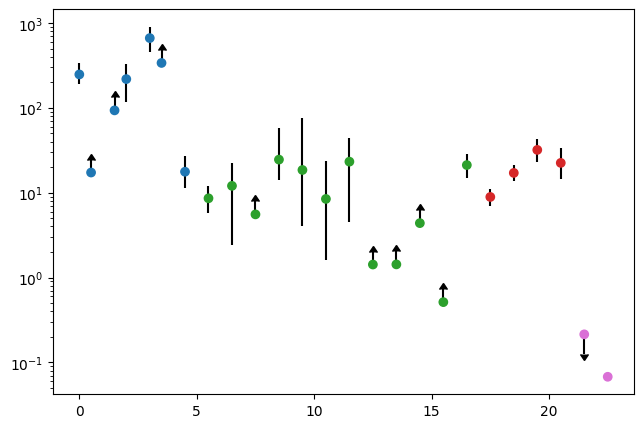

In [8]:
plt.figure(1, figsize=(7.5,5.0))
plt.clf()
rv.errorbar(locs, ratio, fmt=',', color='black')
plt.scatter(locs, ratio.mains, color=colors, zorder=3)
plt.yscale('log')
ax = plt.gca()
plt.show()

Lastly, we complete the plot with more options.

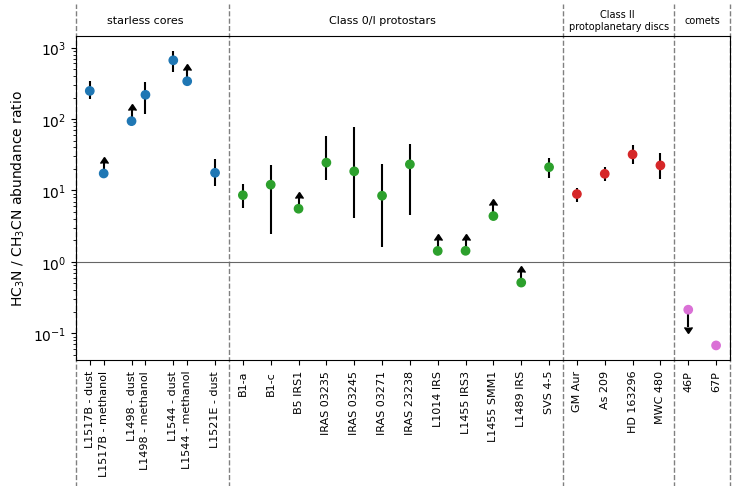

In [9]:
plt.sca(ax)
plot_approx_uncs = False
if plot_approx_uncs:
    col_dens_HC3N = rv.rich_array(data['HC3N'])
    col_dens_CH3CN = rv.rich_array(data['CH3CN'])
    ratio_mains = col_dens_HC3N.mains / col_dens_CH3CN.mains
    ratio_uncs_eb = \
        ratio_mains * ((col_dens_HC3N.uncs_eb/col_dens_HC3N.mains)**2
                       +(col_dens_CH3CN.uncs_eb/col_dens_CH3CN.mains)**2)**0.5
    for i in range(len(ratio_mains)):
        if col_dens_CH3CN[i].is_uplim:
            ratio_mains[i] = ((col_dens_HC3N[i].main - 1*col_dens_HC3N[i].unc[0])
                              / col_dens_CH3CN[i].main)
    ratio_mains[-2] = (col_dens_HC3N[-2].main / (col_dens_CH3CN[-2].main
                       - 1*col_dens_CH3CN[-2].unc[0]))
    cond = np.isfinite(ratio.mains)
    locs_ = locs[cond]
    ratio_mains = ratio_mains[cond]
    ratio_uncs_eb = ratio_uncs_eb[:,cond]
    cond = ~rv.rich_array(ratio[np.isfinite(ratio.mains)]).are_lims
    plt.errorbar(locs_[cond], ratio_mains[cond], yerr=ratio_uncs_eb[:,cond],
                 fmt=',', alpha=0.8, color='orange', zorder=2)
    plt.scatter(locs_, ratio_mains, color='orange', alpha=0.8, zorder=2)
plt.xlim([-0.5, locs[-1] + 0.5])
plt.axhline(y=1, linestyle='-', linewidth=0.8, color=(0.4,0.4,0.4))
cond = ~np.isnan(ratio.mains)
plt.xticks(ticks=locs[cond], labels=names[cond], rotation=90,
           fontsize=0.8*fontsize)
plt.ylabel('HC$_3$N / CH$_3$CN abundance ratio')
y_top_labels = 1.05
ax = plt.gca()
xrange = np.diff(plt.xlim())
edges = np.array([0, 7, 23, 27, 29])
text_locs = []
for i in range(len(edges)-1):
    i1 = edges[i]
    i2 = edges[i+1]
    text_locs += [0.5 + np.median(locs[i1:i2])]
texts = ['starless cores', 'Class 0/I protostars',
         'Class II \nprotoplanetary discs', 'comets']
fontsizes = fontsize*np.array([0.8, 0.8, 0.7, 0.7])
for (i, text, fs) in zip(text_locs, texts, fontsizes):
    plt.text(i/xrange, y_top_labels, text, ha='center', va='center',
             fontsize=fs, transform=ax.transAxes)
line_locs = [locs[0] - 0.5]
line_locs += list(locs[edges[1:-1]] - 0.5)
line_locs += [locs[-1] + 0.5]
for x in line_locs:
    plt.axvline(x, ymin=-0.5, ymax=1.1, linestyle='--', linewidth=1.,
                color='gray', clip_on=False, zorder=0.5)
plt.tight_layout()
plt.show()

That's it! You can change the value of the variable `plot_approx_uncs` in one of the previous cells and re-run the cells of the plot, to see the values that we would obtain using the usual analytical formulas for uncertainty propagation. The approach of RichValues is more precise.